In [33]:
df = pd.read_csv("/content/DT_Placement.csv")


In [34]:
# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.inspection import permutation_importance

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
# ============================================================
# 3. LOAD DATASET
# ============================================================

# Get uploaded file name automatically
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df)

Dataset loaded successfully.
Shape: (14, 6)


,ID,CGPA,Internships,Backlogs,Aptitude,Placed
0,S1,8.6,2,No,73,Yes
1,S2,9.4,2,No,76,Yes
2,S3,9.0,2,No,81,Yes
3,S4,5.2,0,Yes,48,No
4,S5,5.3,0,Yes,44,No
5,S6,5.0,1,No,83,No
6,S7,6.2,1,Yes,63,No
7,S8,6.2,0,Yes,52,Yes
8,S9,8.7,2,Yes,77,Yes
9,S10,7.5,1,No,70,Yes


In [7]:
# ============================================================
# 4. CHECK DATASET
# ============================================================

print("Column Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nFirst 5 Rows:")
display(df.head())

Column Names:
['ID', 'CGPA', 'Internships', 'Backlogs', 'Aptitude', 'Placed']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           14 non-null     object 
 1   CGPA         14 non-null     float64
 2   Internships  14 non-null     int64  
 3   Backlogs     14 non-null     object 
 4   Aptitude     14 non-null     int64  
 5   Placed       14 non-null     object 
dtypes: float64(1), int64(2), object(3)
memory usage: 804.0+ bytes

Missing Values:
ID             0
CGPA           0
Internships    0
Backlogs       0
Aptitude       0
Placed         0
dtype: int64

First 5 Rows:


,ID,CGPA,Internships,Backlogs,Aptitude,Placed
0,S1,8.6,2,No,73,Yes
1,S2,9.4,2,No,76,Yes
2,S3,9.0,2,No,81,Yes
3,S4,5.2,0,Yes,48,No
4,S5,5.3,0,Yes,44,No


In [35]:

# ============================================================
# 5. DATA PREPROCESSING
# ============================================================

data_model = df.copy()

# Remove ID because it is only an identifier
data_model = data_model.drop(columns=["ID"])

# Convert Yes/No into 1/0
mapping = {
    "no": 0,
    "yes": 1
}

for col in ["Backlogs", "Placed"]:
    data_model[col] = (
        data_model[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map(mapping)
    )

print("Preprocessed Dataset:")
display(data_model)

Preprocessed Dataset:


,CGPA,Internships,Backlogs,Aptitude,Placed
0,8.6,2,0,73,1
1,9.4,2,0,76,1
2,9.0,2,0,81,1
3,5.2,0,1,48,0
4,5.3,0,1,44,0
5,5.0,1,0,83,0
6,6.2,1,1,63,0
7,6.2,0,1,52,1
8,8.7,2,1,77,1
9,7.5,1,0,70,1


In [9]:
# ============================================================
# 6. DEFINE FEATURES AND TARGET
# ============================================================

# Input features
X = data_model.drop(columns=["Placed"])

# Target variable
y = data_model["Placed"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Placed")

Features:
['CGPA', 'Internships', 'Backlogs', 'Aptitude']

Target:
Placed


In [10]:
# ============================================================
# 7. TRAIN / VALIDATION SPLIT
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

Training samples: 9
Validation samples: 5

Training class distribution:
Placed
1    5
0    4
Name: count, dtype: int64

Validation class distribution:
Placed
1    3
0    2
Name: count, dtype: int64


In [11]:
# ============================================================
# 8. SINGLE DECISION TREE
# ============================================================

dt_baseline = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt_baseline.fit(X_train, y_train)

dt_train_pred = dt_baseline.predict(X_train)
dt_val_pred = dt_baseline.predict(X_val)

dt_train_acc = accuracy_score(
    y_train,
    dt_train_pred
)

dt_val_acc = accuracy_score(
    y_val,
    dt_val_pred
)

print("SINGLE DECISION TREE")
print("=" * 50)

print(f"Training Accuracy   : {dt_train_acc:.4f}")
print(f"Validation Accuracy : {dt_val_acc:.4f}")
print(f"Tree Depth          : {dt_baseline.get_depth()}")
print(f"Number of Leaves    : {dt_baseline.get_n_leaves()}")

SINGLE DECISION TREE
Training Accuracy   : 1.0000
Validation Accuracy : 0.6000
Tree Depth          : 3
Number of Leaves    : 4


In [12]:
# ============================================================
# 9. RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    criterion="entropy",
    max_features="sqrt",
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_train_pred = rf.predict(X_train)
rf_val_pred = rf.predict(X_val)

rf_train_acc = accuracy_score(
    y_train,
    rf_train_pred
)

rf_val_acc = accuracy_score(
    y_val,
    rf_val_pred
)

print("RANDOM FOREST")
print("=" * 50)

print(f"Number of Trees     : {rf.n_estimators}")
print(f"Training Accuracy   : {rf_train_acc:.4f}")
print(f"Validation Accuracy : {rf_val_acc:.4f}")
print(f"OOB Accuracy        : {rf.oob_score_:.4f}")
print(f"OOB Error           : {1 - rf.oob_score_:.4f}")

RANDOM FOREST
Number of Trees     : 100
Training Accuracy   : 1.0000
Validation Accuracy : 0.8000
OOB Accuracy        : 0.5556
OOB Error           : 0.4444


In [13]:
# ============================================================
# 10. NUMBER OF TREES
# ============================================================

print("Number of trees:", len(rf.estimators_))

Number of trees: 100


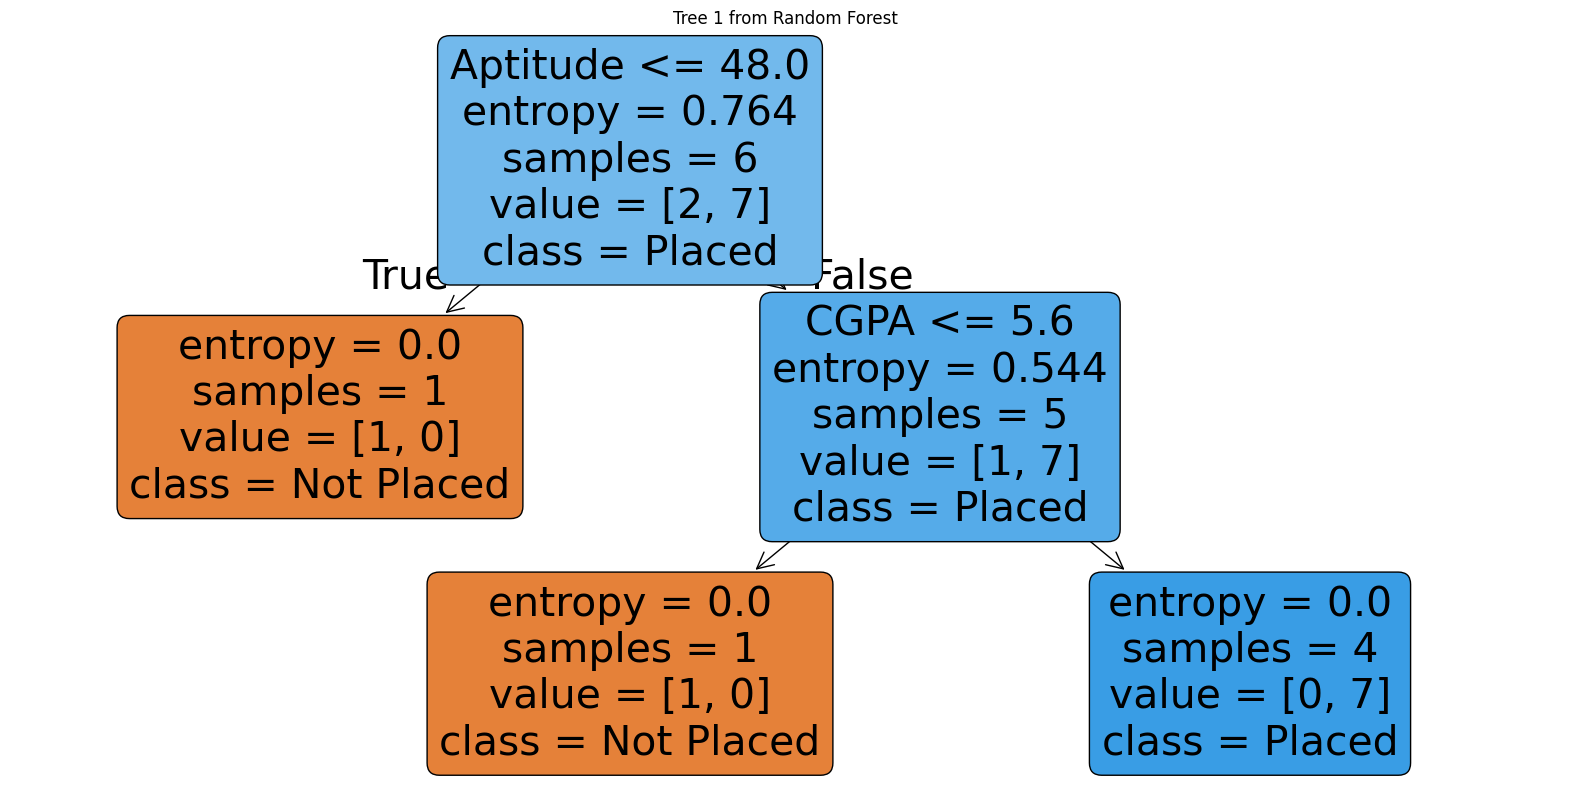

In [14]:
# ============================================================
# 11. FIRST TREE FROM RANDOM FOREST
# ============================================================

plt.figure(figsize=(20, 10))

plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=["Not Placed", "Placed"],
    filled=True,
    rounded=True
)

plt.title("Tree 1 from Random Forest")
plt.show()

In [15]:
# ============================================================
# 12. CLASSIFICATION REPORT
# ============================================================

print("RANDOM FOREST CLASSIFICATION REPORT")
print("=" * 50)

print(
    classification_report(
        y_val,
        rf_val_pred,
        target_names=["Not Placed", "Placed"],
        zero_division=0
    )
)

RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Not Placed       1.00      0.50      0.67         2
      Placed       0.75      1.00      0.86         3

    accuracy                           0.80         5
   macro avg       0.88      0.75      0.76         5
weighted avg       0.85      0.80      0.78         5



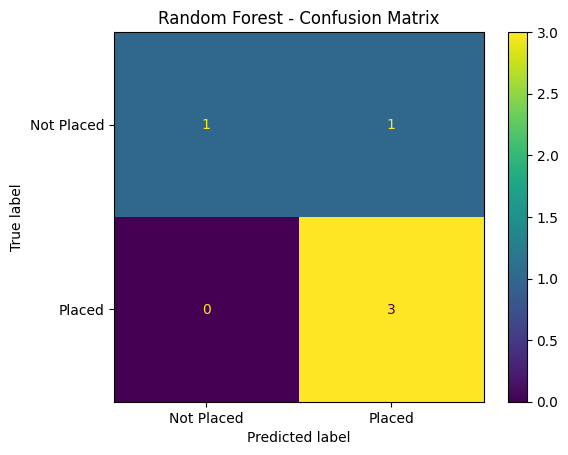

In [16]:
# ============================================================
# 13. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_val,
    rf_val_pred
)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Placed", "Placed"]
).plot()

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [17]:
# ============================================================
# 14. OOB ERROR CONVERGENCE
# ============================================================

n_estimators_values = [
    1, 5, 10, 20, 30,
    50, 75, 100, 150, 200
]

oob_results = []

for n in n_estimators_values:

    model = RandomForestClassifier(
        n_estimators=n,
        criterion="entropy",
        max_features="sqrt",
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    oob_acc = model.oob_score_

    oob_results.append({
        "n_estimators": n,
        "OOB_Accuracy": oob_acc,
        "OOB_Error": 1 - oob_acc
    })

oob_df = pd.DataFrame(oob_results)

display(oob_df.round(4))

/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,n_estimators,OOB_Accuracy,OOB_Error
0,1,0.4444,0.5556
1,5,0.4444,0.5556
2,10,0.5556,0.4444
3,20,0.5556,0.4444
4,30,0.5556,0.4444
5,50,0.5556,0.4444
6,75,0.5556,0.4444
7,100,0.5556,0.4444
8,150,0.5556,0.4444
9,200,0.5556,0.4444


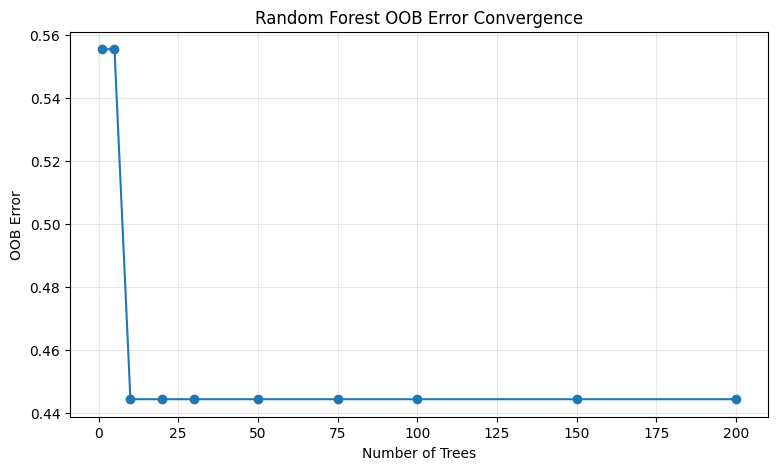

In [18]:
# ============================================================
# 15. OOB ERROR GRAPH
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    oob_df["n_estimators"],
    oob_df["OOB_Error"],
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("OOB Error")
plt.title("Random Forest OOB Error Convergence")

plt.grid(True, alpha=0.3)

plt.show()

In [19]:
# ============================================================
# 16. max_features COMPARISON
# ============================================================

max_features_values = [
    "sqrt",
    "log2",
    None
]

max_features_results = []

for mf in max_features_values:

    model = RandomForestClassifier(
        n_estimators=100,
        criterion="entropy",
        max_features=mf,
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    max_features_results.append({
        "max_features": str(mf),
        "Training_Accuracy": accuracy_score(
            y_train,
            train_pred
        ),
        "Validation_Accuracy": accuracy_score(
            y_val,
            val_pred
        ),
        "OOB_Accuracy": model.oob_score_,
        "OOB_Error": 1 - model.oob_score_
    })

max_features_df = pd.DataFrame(
    max_features_results
)

display(max_features_df.round(4))

,max_features,Training_Accuracy,Validation_Accuracy,OOB_Accuracy,OOB_Error
0,sqrt,1.0,0.8,0.5556,0.4444
1,log2,1.0,0.8,0.5556,0.4444
2,None,1.0,0.6,0.5556,0.4444


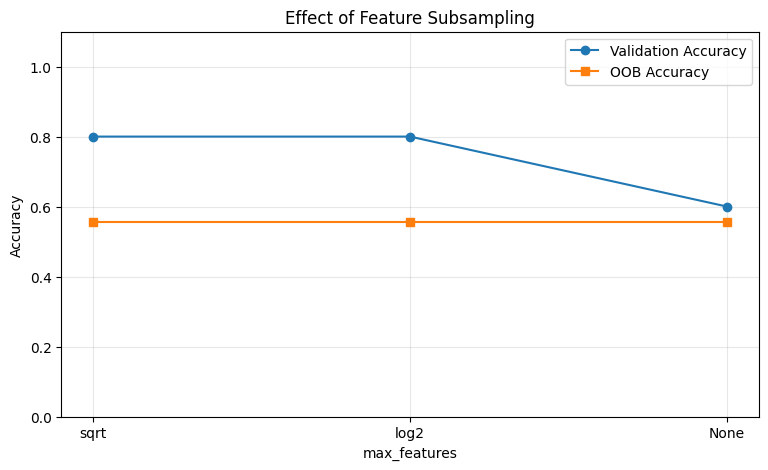

In [20]:
# ============================================================
# 17. FEATURE SUBSAMPLING GRAPH
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    max_features_df["max_features"],
    max_features_df["Validation_Accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.plot(
    max_features_df["max_features"],
    max_features_df["OOB_Accuracy"],
    marker="s",
    label="OOB Accuracy"
)

plt.xlabel("max_features")
plt.ylabel("Accuracy")
plt.title("Effect of Feature Subsampling")

plt.legend()
plt.ylim(0, 1.1)
plt.grid(True, alpha=0.3)

plt.show()

In [21]:
# ============================================================
# 18. MANUAL BOOTSTRAP SAMPLE
# ============================================================

rng = np.random.default_rng(42)

indices = rng.choice(
    np.arange(len(X_train)),
    size=len(X_train),
    replace=True
)

unique_indices = np.unique(indices)

oob_indices = np.setdiff1d(
    np.arange(len(X_train)),
    unique_indices
)

print("Bootstrap indices:")
print(indices)

print("\nUnique selected rows:")
print(unique_indices)

print("\nOOB row indices:")
print(oob_indices)

print("\nTotal bootstrap observations:", len(indices))
print("Unique observations:", len(unique_indices))
print("OOB observations:", len(oob_indices))

Bootstrap indices:
[0 6 5 3 3 7 0 6 1]

Unique selected rows:
[0 1 3 5 6 7]

OOB row indices:
[2 4 8]

Total bootstrap observations: 9
Unique observations: 6
OOB observations: 3


In [22]:
# ============================================================
# 19. MANUAL BAGGING
# ============================================================

N_MANUAL_TREES = 50

manual_trees = []

rng = np.random.default_rng(42)

for tree_number in range(N_MANUAL_TREES):

    sample_indices = rng.choice(
        np.arange(len(X_train)),
        size=len(X_train),
        replace=True
    )

    X_boot = X_train.iloc[sample_indices]
    y_boot = y_train.iloc[sample_indices]

    tree = DecisionTreeClassifier(
        criterion="entropy",
        random_state=tree_number
    )

    tree.fit(
        X_boot,
        y_boot
    )

    manual_trees.append(tree)

print(
    f"{N_MANUAL_TREES} manually bagged trees trained."
)

50 manually bagged trees trained.


In [23]:
# ============================================================
# 20. MANUAL BAGGING - MAJORITY VOTE
# ============================================================

tree_predictions = np.array([
    tree.predict(X_val)
    for tree in manual_trees
])

manual_bagging_pred = (
    np.mean(tree_predictions, axis=0) >= 0.5
).astype(int)

manual_bagging_acc = accuracy_score(
    y_val,
    manual_bagging_pred
)

print(
    "Manual Bootstrap Bagging Validation Accuracy:",
    f"{manual_bagging_acc:.4f}"
)

Manual Bootstrap Bagging Validation Accuracy: 0.6000


In [24]:
# ============================================================
# 21. BAGGING CLASSIFIER
# ============================================================

bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(
        criterion="entropy",
        random_state=42
    ),
    n_estimators=100,
    max_samples=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging.fit(
    X_train,
    y_train
)

bagging_train_pred = bagging.predict(X_train)
bagging_val_pred = bagging.predict(X_val)

print("BAGGING PERFORMANCE")
print("=" * 50)

print(
    f"Training Accuracy   : "
    f"{accuracy_score(y_train, bagging_train_pred):.4f}"
)

print(
    f"Validation Accuracy : "
    f"{accuracy_score(y_val, bagging_val_pred):.4f}"
)

BAGGING PERFORMANCE
Training Accuracy   : 1.0000
Validation Accuracy : 0.6000


In [25]:
# ============================================================
# 22. PERMUTATION IMPORTANCE
# ============================================================

perm = permutation_importance(
    rf,
    X_val,
    y_val,
    n_repeats=30,
    random_state=42,
    scoring="accuracy"
)

importance_df = pd.DataFrame({
    "Feature": X_val.columns,
    "Mean_Importance": perm.importances_mean,
    "Std_Importance": perm.importances_std
}).sort_values(
    "Mean_Importance",
    ascending=False
).reset_index(drop=True)

print("PERMUTATION IMPORTANCE")
print("=" * 50)

display(
    importance_df.round(4)
)

PERMUTATION IMPORTANCE


,Feature,Mean_Importance,Std_Importance
0,Internships,0.2200,0.1194
1,CGPA,0.1333,0.0943
2,Aptitude,0.0467,0.0846
3,Backlogs,0.0000,0.0000


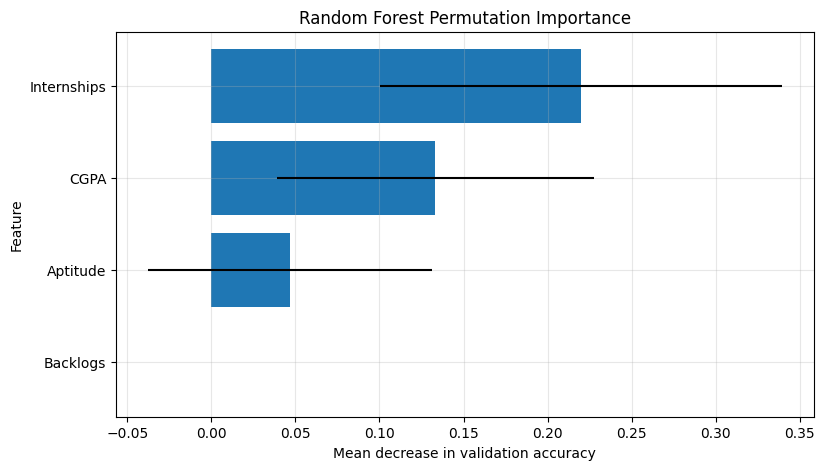

In [26]:
# ============================================================
# 23. PLOT PERMUTATION IMPORTANCE
# ============================================================

plt.figure(figsize=(9, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Mean_Importance"],
    xerr=importance_df["Std_Importance"]
)

plt.xlabel(
    "Mean decrease in validation accuracy"
)

plt.ylabel("Feature")

plt.title(
    "Random Forest Permutation Importance"
)

plt.gca().invert_yaxis()

plt.grid(True, alpha=0.3)

plt.show()

In [27]:
# ============================================================
# 24. RANDOM FOREST VS SINGLE DECISION TREE
# ============================================================

n_estimators_list = [
    1, 5, 10, 20, 50, 100, 150, 200
]

results = []

# ------------------------------------------------------------
# Single Decision Tree
# ------------------------------------------------------------

dt = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_val_acc = accuracy_score(
    y_val,
    dt.predict(X_val)
)

# ------------------------------------------------------------
# Random Forests
# ------------------------------------------------------------

for n in n_estimators_list:

    rf_model = RandomForestClassifier(
        n_estimators=n,
        criterion="entropy",
        max_features="sqrt",
        bootstrap=True,
        oob_score=True,
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(
        X_train,
        y_train
    )

    rf_val_acc = accuracy_score(
        y_val,
        rf_model.predict(X_val)
    )

    results.append({
        "Number_of_Trees": n,
        "RF_Validation_Accuracy": rf_val_acc,
        "DT_Validation_Accuracy": dt_val_acc,
        "RF_OOB_Accuracy": rf_model.oob_score_
    })

comparison_df = pd.DataFrame(results)

display(
    comparison_df.round(4)
)

/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/usr/local/lib/python3.13/dist-packages/sklearn/ensemble/_forest.py:612: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,Number_of_Trees,RF_Validation_Accuracy,DT_Validation_Accuracy,RF_OOB_Accuracy
0,1,0.8,0.6,0.4444
1,5,0.8,0.6,0.4444
2,10,0.8,0.6,0.5556
3,20,0.8,0.6,0.5556
4,50,0.8,0.6,0.5556
5,100,0.8,0.6,0.5556
6,150,0.8,0.6,0.5556
7,200,0.8,0.6,0.5556


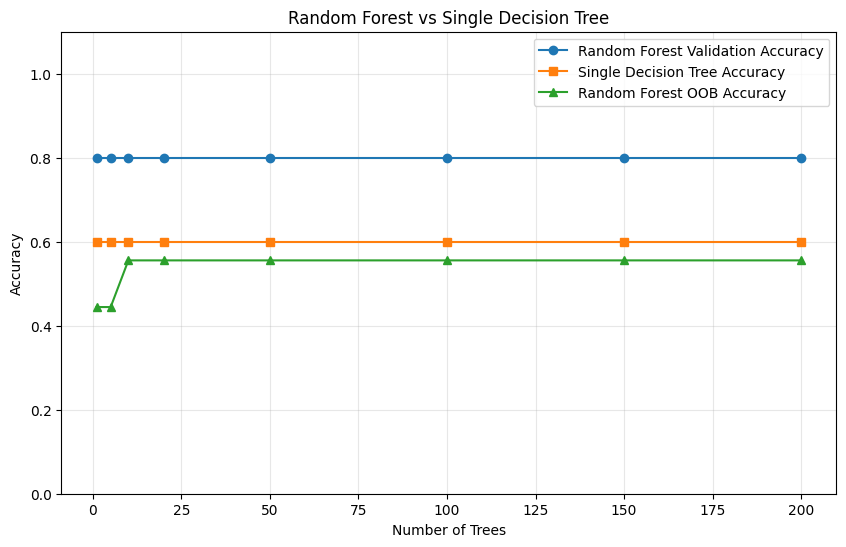

In [28]:
# ============================================================
# 25. FINAL COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    comparison_df["Number_of_Trees"],
    comparison_df["RF_Validation_Accuracy"],
    marker="o",
    label="Random Forest Validation Accuracy"
)

plt.plot(
    comparison_df["Number_of_Trees"],
    comparison_df["DT_Validation_Accuracy"],
    marker="s",
    label="Single Decision Tree Accuracy"
)

plt.plot(
    comparison_df["Number_of_Trees"],
    comparison_df["RF_OOB_Accuracy"],
    marker="^",
    label="Random Forest OOB Accuracy"
)

plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")

plt.title(
    "Random Forest vs Single Decision Tree"
)

plt.legend()

plt.ylim(0, 1.1)

plt.grid(True, alpha=0.3)

plt.show()

In [29]:
# ============================================================
# 26. FINAL SUMMARY
# ============================================================

print("=" * 60)
print("PRACTICAL 7 - FINAL SUMMARY")
print("=" * 60)

print("\nSINGLE DECISION TREE")
print(f"Training Accuracy   : {dt_train_acc:.4f}")
print(f"Validation Accuracy : {dt_val_acc:.4f}")

print("\nRANDOM FOREST")
print(f"Number of Trees     : {rf.n_estimators}")
print(f"Training Accuracy   : {rf_train_acc:.4f}")
print(f"Validation Accuracy : {rf_val_acc:.4f}")
print(f"OOB Accuracy        : {rf.oob_score_:.4f}")
print(f"OOB Error           : {1 - rf.oob_score_:.4f}")

print("\nMANUAL BAGGING")
print(f"Validation Accuracy : {manual_bagging_acc:.4f}")

print("\nBAGGING CLASSIFIER")
print(
    f"Validation Accuracy : "
    f"{accuracy_score(y_val, bagging_val_pred):.4f}"
)

print("\n" + "=" * 60)
print("PRACTICAL COMPLETED SUCCESSFULLY")
print("=" * 60)

PRACTICAL 7 - FINAL SUMMARY

SINGLE DECISION TREE
Training Accuracy   : 1.0000
Validation Accuracy : 0.6000

RANDOM FOREST
Number of Trees     : 100
Training Accuracy   : 1.0000
Validation Accuracy : 0.8000
OOB Accuracy        : 0.5556
OOB Error           : 0.4444

MANUAL BAGGING
Validation Accuracy : 0.6000

BAGGING CLASSIFIER
Validation Accuracy : 0.6000

PRACTICAL COMPLETED SUCCESSFULLY
